# 1 — Data Preparation & Embedding Generation
**Author:** Kruthika Shantha Murthy

This notebook:
1. Loads and explores the **WELFake** dataset (72 134 articles)
2. Cleans and combines title + text
3. Computes **sentence-level** embeddings with `all-MiniLM-L6-v2` (384-dim)
4. Caches embeddings to disk for all downstream notebooks

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.pardir, "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from config import (
    DATASET_PATH, EMBEDDINGS_CACHE, LABELS_CACHE,
    LLM_MODEL_NAME, EMBEDDING_DIM, MAX_SENTENCES,
    TEXT_COLUMN, TITLE_COLUMN, LABEL_COLUMN,
    CACHE_DIR, RANDOM_SEED,
)
from data_utils import load_dataset, compute_embeddings

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 120

## 1.1 Load raw dataset

In [2]:
df = pd.read_csv(DATASET_PATH)
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nMissing values:\n{df.isnull().sum()}")
df.head(3)

Shape: (72134, 4)
Columns: ['Unnamed: 0', 'title', 'text', 'label']

Missing values:
Unnamed: 0      0
title         558
text           39
label           0
dtype: int64


,Unnamed: 0,title,text,label
0,0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,1,NaN,Did they post their votes for Hillary already?,1
2,2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1


## 1.2 Label distribution

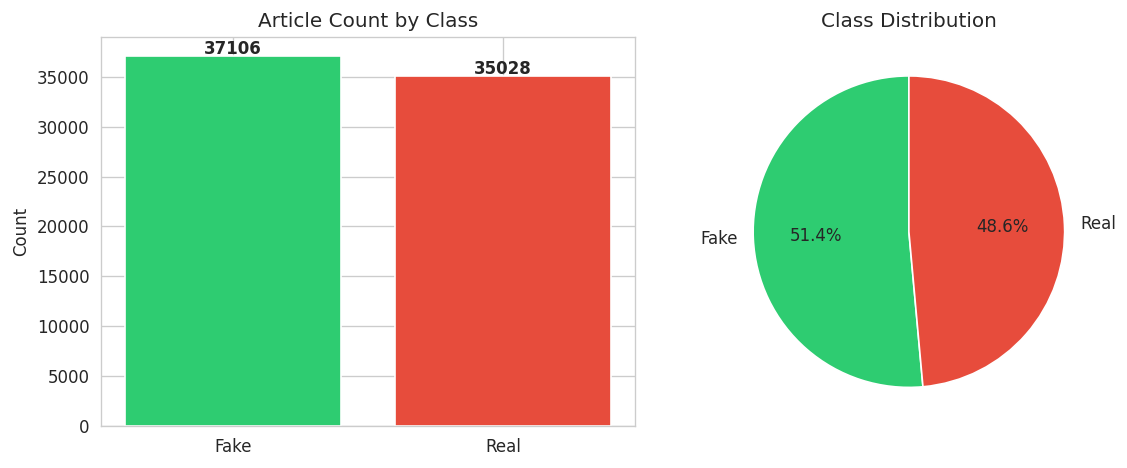


Fake: 37,106  |  Real: 35,028


In [3]:
label_counts = df[LABEL_COLUMN].value_counts()
label_names = {0: "Real", 1: "Fake"}

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar([label_names[i] for i in label_counts.index],
            label_counts.values, color=["#2ecc71", "#e74c3c"])
axes[0].set_title("Article Count by Class")
axes[0].set_ylabel("Count")
for i, v in enumerate(label_counts.values):
    axes[0].text(i, v + 200, str(v), ha="center", fontweight="bold")

axes[1].pie(label_counts.values, labels=[label_names[i] for i in label_counts.index],
            autopct="%1.1f%%", colors=["#2ecc71", "#e74c3c"], startangle=90)
axes[1].set_title("Class Distribution")

plt.tight_layout()
plt.show()

print(f"\nFake: {label_counts.get(1, 0):,}  |  Real: {label_counts.get(0, 0):,}")

## 1.3 Text length analysis

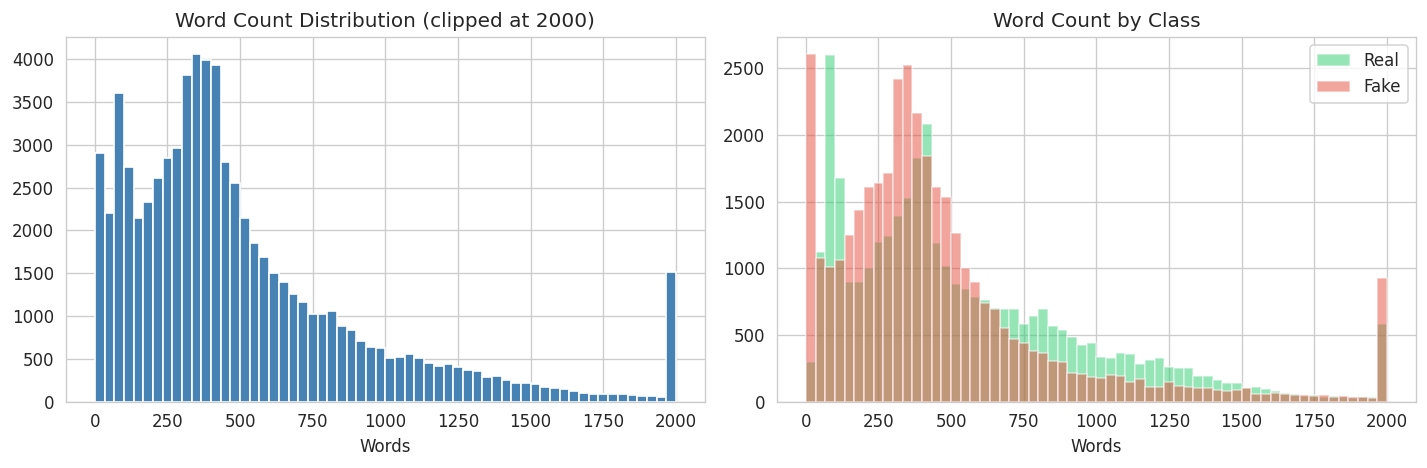

       text_len  word_count
count   72134.0     72134.0
mean     3268.4       540.6
std      3732.9       625.4
min         0.0         0.0
25%      1377.0       227.0
50%      2424.0       398.0
75%      4059.0       667.0
max    142961.0     24234.0


In [4]:
df["text_len"] = df[TEXT_COLUMN].fillna("").apply(len)
df["word_count"] = df[TEXT_COLUMN].fillna("").apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df["word_count"].clip(upper=2000), bins=60, color="steelblue", edgecolor="white")
axes[0].set_title("Word Count Distribution (clipped at 2000)")
axes[0].set_xlabel("Words")

for label_val, color in [(0, "#2ecc71"), (1, "#e74c3c")]:
    subset = df[df[LABEL_COLUMN] == label_val]["word_count"].clip(upper=2000)
    axes[1].hist(subset, bins=60, alpha=0.5, label=label_names[label_val], color=color)
axes[1].set_title("Word Count by Class")
axes[1].set_xlabel("Words")
axes[1].legend()

plt.tight_layout()
plt.show()

print(df[["text_len", "word_count"]].describe().round(1))

## 1.4 Data cleaning

In [5]:
texts, labels = load_dataset(DATASET_PATH)
print(f"Loaded {len(texts):,} articles after dropping NaN")
print(f"Label distribution: Fake={sum(labels==1):,}  Real={sum(labels==0):,}")
print(f"\nSample (first 200 chars):\n{texts[0][:200]}...")

Loaded 72,095 articles after dropping NaN
Label distribution: Fake=37,067  Real=35,028

Sample (first 200 chars):
LAW ENFORCEMENT ON HIGH ALERT Following Threats Against Cops And Whites On 9-11By #BlackLivesMatter And #FYF911 Terrorists [VIDEO]. No comment is expected from Barack Obama Members of the #FYF911 or #...


## 1.5 Compute sentence-level LLM embeddings

Each article is split into sentences, and each sentence is embedded
with `all-MiniLM-L6-v2` (384-dim). The result is a matrix of shape
`(N, 16, 384)` — 16 sentence embeddings per article, zero-padded
for shorter articles.

**This step is cached**: re-running this cell is instant after the first run.

In [6]:
import torch
print(torch.cuda.is_available())   # should print True
print(torch.cuda.device_count())   # should print 4

True
4


In [7]:
embeddings = compute_embeddings(
    texts,
    model_name=LLM_MODEL_NAME,
    max_sentences=MAX_SENTENCES,
    embedding_dim=EMBEDDING_DIM,
    cache_path=EMBEDDINGS_CACHE,
)

os.makedirs(os.path.dirname(LABELS_CACHE), exist_ok=True)
np.save(LABELS_CACHE, labels)

print(f"\nEmbeddings shape: {embeddings.shape}")
print(f"Labels shape:     {labels.shape}")
print(f"Dtype:            {embeddings.dtype}")

[data] Loading embedding model: sentence-transformers/all-MiniLM-L6-v2


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Segmented 10000/72095 articles
  Segmented 20000/72095 articles
  Segmented 30000/72095 articles
  Segmented 40000/72095 articles
  Segmented 50000/72095 articles
  Segmented 60000/72095 articles
  Segmented 70000/72095 articles
[data] 917,754 sentences from 72,095 articles
[data] Encoding (may take a few minutes on GPU, longer on CPU) ...


Batches:   0%|          | 0/3585 [00:00<?, ?it/s]

[data] Saved cache (845 MB) -> /home/katarir/Downloads/ai/FINAL/cache/sentence_embeddings.npy

Embeddings shape: (72095, 16, 384)
Labels shape:     (72095,)
Dtype:            float32


## 1.6 Verify embeddings

Avg sentences per article: 12.7
Min: 1  Max: 16


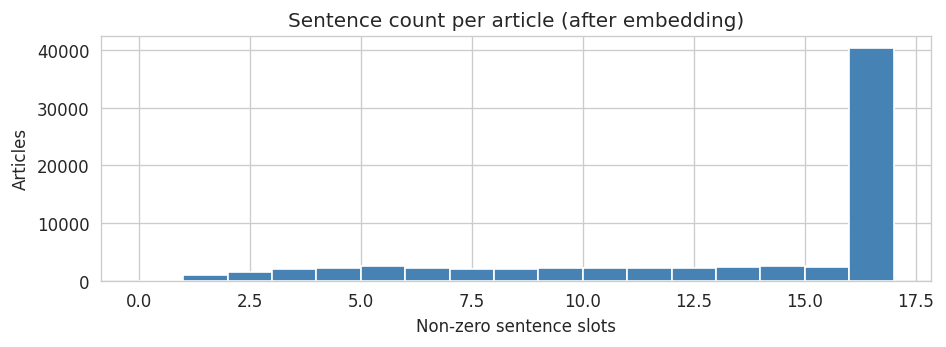

In [8]:
nonzero_sents = (embeddings.sum(axis=-1) != 0).sum(axis=1)
print(f"Avg sentences per article: {nonzero_sents.mean():.1f}")
print(f"Min: {nonzero_sents.min()}  Max: {nonzero_sents.max()}")

plt.figure(figsize=(8, 3))
plt.hist(nonzero_sents, bins=range(0, MAX_SENTENCES + 2), color="steelblue", edgecolor="white")
plt.xlabel("Non-zero sentence slots")
plt.ylabel("Articles")
plt.title("Sentence count per article (after embedding)")
plt.tight_layout()
plt.show()

## Summary

| Item | Value |
| --- | --- |
| Dataset | WELFake (72 134 articles) |
| Embedding model | `all-MiniLM-L6-v2` (384-dim) |
| Representation | 16 sentence embeddings per article |
| Cache file | `cache/sentence_embeddings.npy` |

Proceed to **Notebook 2** to train baseline models.